# Avaliação e Inferência - YOLOv11

Notebook dedicado à validação final e inferência do modelo treinado.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = ["ultralytics", "torch", "matplotlib", "Pillow", "numpy", "pandas"]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg.replace("Pillow", "PIL")) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Dependências instaladas:", ", ".join(missing))
else:
    print("Dependências já instaladas.")

Dependências já instaladas.


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from IPython.display import display

In [3]:
import torch

PROJECT_ROOT = Path.cwd()
BASE_DIR = PROJECT_ROOT / "pcb-defect-subset-5000"
RUNS_ROOT = PROJECT_ROOT / "runs" / "detect"

RUNS_DIR = RUNS_ROOT / "tcc_pcb_defect_detection" / "yolo11"

EVAL_OUT_DIR = RUNS_ROOT / "eval_results"
EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = 0
else:
    DEVICE = "cpu"

EVAL_DEVICE = "cpu" if DEVICE == "mps" else DEVICE

if not BASE_DIR.exists():
    raise FileNotFoundError(f"Dataset não encontrado: {BASE_DIR}")

candidate_weights = sorted(RUNS_DIR.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not candidate_weights:
    raise FileNotFoundError("Nenhum arquivo best.pt foi encontrado nos diretorios de experimentos")

MODEL_PATH = candidate_weights[0]
TEST_IMAGES_DIR = BASE_DIR / "test" / "images"

print(f"Device detectado: {DEVICE}")
print(f"Device em uso para avaliacao: {EVAL_DEVICE}")
print(f"Modelo selecionado: {MODEL_PATH}")
print(f"Imagens de teste: {TEST_IMAGES_DIR}")
print(f"Saidas de avaliacao: {EVAL_OUT_DIR}")

Device detectado: mps
Device em uso para avaliacao: cpu
Modelo selecionado: /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/yolo11/20260405_1422_yolo11n_img640_e50_bs16_seed42_baseline/weights/best.pt
Imagens de teste: /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/test/images
Saidas de avaliacao: /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results


In [4]:
model = YOLO(str(MODEL_PATH))
metrics = model.val(data=str(BASE_DIR / "data.yaml"), split="test", device=EVAL_DEVICE)

summary = {
    "device_detected": str(DEVICE),
    "device_used": str(EVAL_DEVICE),
    "map50": float(metrics.box.map50),
    "map50_95": float(metrics.box.map),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
}

with open(EVAL_OUT_DIR / "metrics_eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(summary)
print(f"Resumo salvo em: {EVAL_OUT_DIR / 'metrics_eval_summary.json'}")

Ultralytics 8.4.31 🚀 Python-3.14.3 torch-2.11.0 CPU (Apple M4)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 505.4±81.0 MB/s, size: 110.7 KB)
val: Scanning /Users/alehholiveira/Desktop/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/test/labels.cache... 413 images, 119 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 532/532 37.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 2.1s/it 1:112.1sss
                   all        532        818      0.971      0.971      0.984      0.523
            mouse_bite         60        117      0.939      0.991      0.984      0.481
                  spur         81        157       0.97      0.955       0.98      0.517
          missing_hole         80        154      0.978      0.994      0.993      0.594
                 short         65        122      

In [5]:
def infer_and_plot(image_paths, conf=0.25):
    image_paths = [Path(p) for p in image_paths]
    outputs = []

    # Recarrega o modelo para evitar estado interno compartilhado apos validacao
    predict_model = YOLO(str(MODEL_PATH))

    for image_path in image_paths:
        if not image_path.exists():
            print(f"Arquivo não encontrado: {image_path}")
            continue

        results = predict_model.predict(str(image_path), conf=conf, device=EVAL_DEVICE, verbose=False)
        for result in results:
            im_array = result.plot()
            im = Image.fromarray(im_array[..., ::-1])
            out_file = EVAL_OUT_DIR / f"pred_{image_path.stem}.png"
            im.save(out_file)

            plt.figure(figsize=(10, 10))
            plt.imshow(im)
            plt.axis("off")
            plt.title(f"{image_path.name} | detecções: {len(result.boxes)}")
            display(im)

            outputs.append({
                "image": str(image_path),
                "output": str(out_file),
                "detections": int(len(result.boxes)),
            })

    return outputs

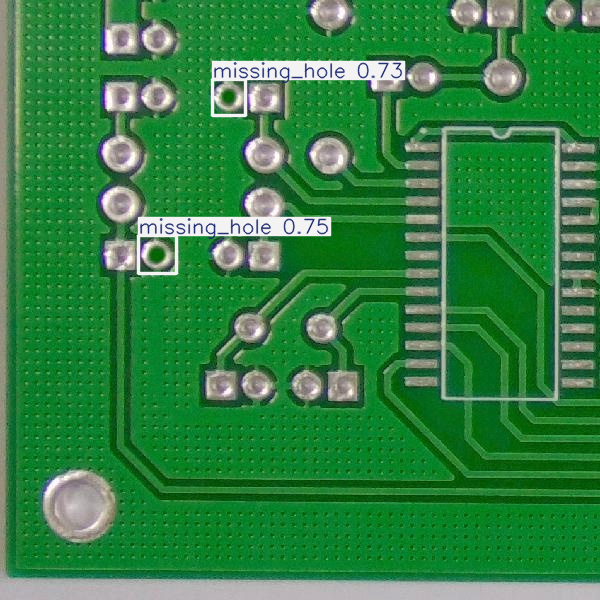

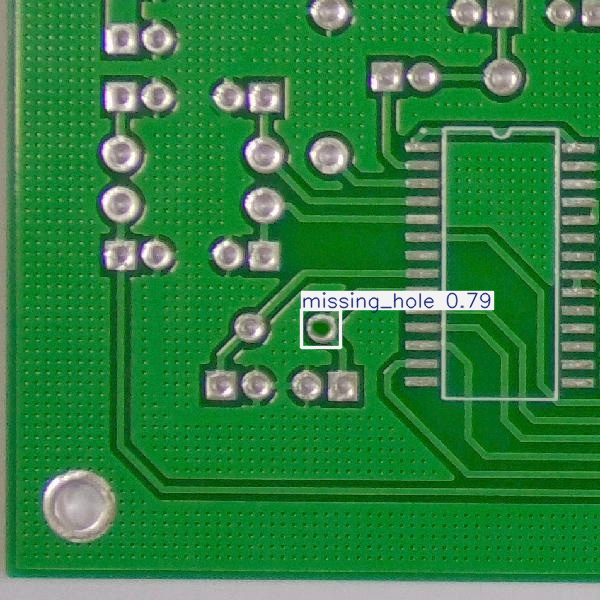

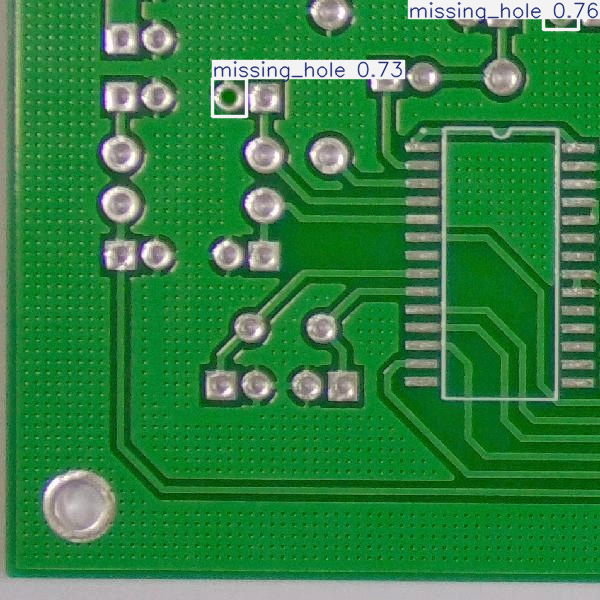

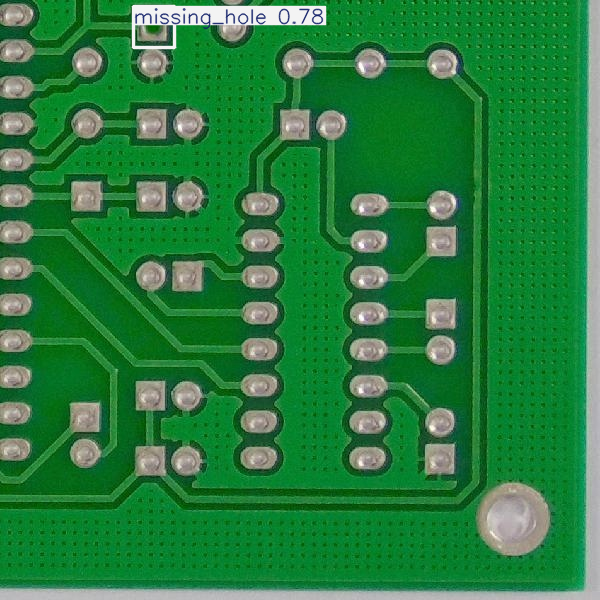

,image,output,detections
0,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,2
1,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,1
2,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,2
3,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,/Users/alehholiveira/Desktop/Projetos/pcb-defe...,1


In [6]:
test_candidates = []
for pattern in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    test_candidates.extend(sorted(TEST_IMAGES_DIR.glob(pattern)))

# Remove duplicatas mantendo ordem
seen = set()
unique_candidates = []
for p in test_candidates:
    if p not in seen:
        unique_candidates.append(p)
        seen.add(p)

test_candidates = unique_candidates[:4]

if not test_candidates:
    raise FileNotFoundError(f"Nenhuma imagem de teste encontrada em: {TEST_IMAGES_DIR}")

infer_results = infer_and_plot(test_candidates, conf=0.25)
results_df = pd.DataFrame(infer_results)
results_df